In [ ]:
# ==============================================================================
# SÚPER CELDA: ESTUDIO DE ABLACIÓN TABM (SEMILLAS FIJAS + VALIDACIÓN MAE)
# ==============================================================================
!pip install tabm -q

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tabm import TabM
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
import gc
import random

# ------------------------------------------------------------
# 0. FIJAR ALEATORIEDAD (REPRODUCIBILIDAD ABSOLUTA)
# ------------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Semillas de aleatoriedad fijadas (Seed=42).")

# ------------------------------------------------------------
# 1. CONFIGURACIÓN Y DATOS
# ------------------------------------------------------------
drive.mount('/content/drive')
CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_Ablacion"
OUTPUT_DIR_TABM.mkdir(exist_ok=True)

TARGET = 'pct_baja'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
IMPORTE_COL = 'lote_importe_adjudicacion_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'

def limpiar_df_estricto(df):
    if TARGET not in df.columns:
        df[TARGET] = ((df[PRESUPUESTO].replace(0, np.nan) - df[IMPORTE_COL]) / df[PRESUPUESTO].replace(0, np.nan)) * 100
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO, IMPORTE_COL], inplace=True)
    df = df[(df[TARGET] >= 0.0) & (df[TARGET] <= 100.0)].copy()
    return df

print("--- Cargando y limpiando datos ---")
train_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
val_df   = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "val_procesado_v2_limpio.parquet"))
test_df_intacto = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))
test_df = test_df_intacto.copy()

DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'lote_importe_adjudicacion_sin_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'presupuesto_base_sin_impuestos', 'duracion_proceso_dias', 'es_anomalia_temporal']

for df in [train_df, val_df, test_df]:
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_val_num   = scaler.transform(val_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_val_cat   = encoder.transform(val_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)

    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_val_cat[:, i]   = np.where(X_val_cat[:, i] == -1, c_len, X_val_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

y_train = torch.tensor(train_df[TARGET].values, dtype=torch.float32)
y_val   = torch.tensor(val_df[TARGET].values, dtype=torch.float32)
y_true  = test_df_intacto[TARGET].values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 2. BUCLE DE EXPERIMENTOS (MSE vs L1 vs Huber)
# ------------------------------------------------------------
experimentos = {
    "MSE": nn.MSELoss(),
    "L1_MAE": nn.L1Loss(),
    "Huber": nn.HuberLoss(delta=5.0)
}

resultados = {}
diccionario_predicciones = {}
diccionario_errores_euros = {}

epochs = 50
batch_size = 256
patience = 7

print(f"\n🚀 Iniciando Estudio de Ablación TabM en {device}...")

for nombre_exp, loss_fn in experimentos.items():
    print(f"\n" + "="*50)
    print(f"ENTRENANDO MODELO: {nombre_exp}")
    print("="*50)

    # IMPORTANTE: Re-fijamos la semilla al instanciar cada modelo para que
    # la inicialización de los pesos sea idéntica en los 3 casos.
    set_seed(42)
    model = TabM.make(n_num_features=len(numerical_cols), cat_cardinalities=cat_cardinalities if categorical_cols else None, d_out=1, k=32).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    ruta_guardado = CARPETA_TFG / f"TabM_best_weights_{nombre_exp}.pth"

    best_val_mae = np.inf # Ahora guardamos en base al MAE
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(len(X_train_num))
        for i in range(0, len(X_train_num), batch_size):
            idx = indices[i:i+batch_size]
            x_n = torch.tensor(X_train_num[idx], dtype=torch.float32).to(device)
            y_b = y_train[idx].to(device)
            optimizer.zero_grad()

            if categorical_cols:
                x_c = torch.tensor(X_train_cat[idx], dtype=torch.long).to(device)
                preds = model(x_n, x_c).squeeze(-1)
            else:
                preds = model(x_n).squeeze(-1)

            # Entrenamos usando la Loss específica del experimento sobre las K redes
            loss = loss_fn(preds, y_b.unsqueeze(1).expand_as(preds))
            loss.backward()
            optimizer.step()

        # --- VALIDACIÓN HOMOGÉNEA (OPCIÓN B: Siempre MAE sobre la media) ---
        model.eval()
        val_maes_batch = []
        with torch.no_grad():
            for j in range(0, len(X_val_num), batch_size):
                x_v_n = torch.tensor(X_val_num[j:j+batch_size], dtype=torch.float32).to(device)
                y_v_b = y_val[j:j+batch_size].to(device)

                if categorical_cols:
                    x_v_c = torch.tensor(X_val_cat[j:j+batch_size], dtype=torch.long).to(device)
                    val_out = model(x_v_n, x_v_c).squeeze(-1).mean(dim=1)
                else:
                    val_out = model(x_v_n).squeeze(-1).mean(dim=1)

                # Usamos L1Loss nativo de PyTorch para calcular el MAE del batch
                batch_mae = torch.nn.functional.l1_loss(val_out, y_v_b).item()
                val_maes_batch.append(batch_mae)

        # La métrica decisiva para guardar el modelo es el MAE de validación
        val_mae = np.mean(val_maes_batch)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), ruta_guardado)
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"  -> Early stopping en epoch {epoch+1} (Val MAE: {val_mae:.4f})")
                break

    # ------------------------------------------------------------
    # INFERENCIA Y MÉTRICAS DEL EXPERIMENTO
    # ------------------------------------------------------------
    model.load_state_dict(torch.load(ruta_guardado))
    model.eval()
    y_preds_final = []

    with torch.no_grad():
        for i in range(0, len(X_test_num), batch_size):
            x_t_n = torch.tensor(X_test_num[i:i+batch_size], dtype=torch.float32).to(device)
            if categorical_cols:
                x_t_c = torch.tensor(X_test_cat[i:i+batch_size], dtype=torch.long).to(device)
                test_out = model(x_t_n, x_t_c).squeeze(-1).mean(dim=1)
            else:
                test_out = model(x_t_n).squeeze(-1).mean(dim=1)
            y_preds_final.extend(test_out.cpu().numpy())

    y_pred = np.array(y_preds_final)
    diccionario_predicciones[nombre_exp] = y_pred

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mdape = np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.sum(mask) > 0 else 0

    importe_predicho = test_df_intacto[PRESUPUESTO] * (1 - (y_pred / 100))
    errores_absolutos_euros = abs(test_df_intacto[IMPORTE_COL] - importe_predicho)
    mae_euros = errores_absolutos_euros.mean()

    diccionario_errores_euros[nombre_exp] = errores_absolutos_euros.values

    print(f"\n--- Resultados Test ({nombre_exp}) ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE (%): {mae:.4f}")
    print(f"MdAPE: {mdape:.4f} %")
    print(f"MAE en Euros: {mae_euros:,.2f} €")

    del model
    torch.cuda.empty_cache()
    gc.collect()

# ------------------------------------------------------------
# 3. GENERACIÓN DE GRÁFICOS COMPARATIVOS PARA TFG
# ------------------------------------------------------------
print("\n" + "="*50)
print("--- Generando gráficos comparativos robustos ---")

mask_valid = (y_true != 0) & (~np.isnan(y_true))
y_true_clean = y_true[mask_valid]

colores = {'MSE': '#1f77b4', 'L1_MAE': '#2ca02c', 'Huber': '#d62728'} # Colores profesionales

# 3.1 SCATTER PLOTS (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Estudio de Ablación TabM: Efecto de la Función de Pérdida en la Capacidad Predictiva', fontsize=18, fontweight='bold')

for ax, nombre_exp in zip(axes, experimentos.keys()):
    y_pred_clean = diccionario_predicciones[nombre_exp][mask_valid]

    ax.scatter(y_true_clean, y_pred_clean, alpha=0.05, color=colores[nombre_exp], s=10)
    ax.plot([-5, 60], [-5, 60], color='black', linestyle='--', linewidth=2)
    ax.set_title(f'Optimización: {nombre_exp}', fontsize=14)
    ax.set_xlabel('Baja REAL (%)', fontsize=12)
    ax.set_xlim(-5, 60)
    ax.set_ylim(-5, 60)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel('Baja PREDICHA (%)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_TABM / '1_Comparativa_Scatter_TabM.png', dpi=300)
plt.close()

# 3.2 BOXPLOT DE ERRORES EN EUROS
plt.figure(figsize=(10, 6))
df_errores = pd.DataFrame(diccionario_errores_euros)

sns.boxplot(data=df_errores, palette=colores, showfliers=False, width=0.5)
plt.title('Distribución del Error Absoluto en Euros por Función de Pérdida', fontsize=14, fontweight='bold')
plt.ylabel('Error Absoluto (€)', fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR_TABM / '2_Comparativa_Boxplot_Euros.png', dpi=300)
plt.close()

# 3.3 HISTOGRAMA DE RESIDUOS (SIN SUAVIZADO ENGAÑOSO)
plt.figure(figsize=(12, 6))
for nombre_exp in experimentos.keys():
    residuos = y_true_clean - diccionario_predicciones[nombre_exp][mask_valid]
    # Usamos element='step' para ver las barras reales sin curvas inventadas
    sns.histplot(residuos, label=nombre_exp, color=colores[nombre_exp],
                 element='step', fill=False, stat='density', common_norm=False, linewidth=2)

plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribución Real de los Residuos (Histograma Escalonado)', fontsize=14, fontweight='bold')
plt.xlabel('Error Real - Error Predicho (%)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.xlim(-40, 40)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_TABM / '3_Comparativa_Residuos_TabM_Real.png', dpi=300)
plt.close()

print(f"✅ ¡Todo completado! Los 3 gráficos están en: {OUTPUT_DIR_TABM.name}")

✅ Semillas de aleatoriedad fijadas (Seed=42).
Mounted at /content/drive
--- Cargando y limpiando datos ---

🚀 Iniciando Estudio de Ablación TabM en cuda...

ENTRENANDO MODELO: MSE
  -> Early stopping en epoch 18 (Val MAE: 9.9604)

--- Resultados Test (MSE) ---
R2 Score: 0.1024
MAE (%): 10.2115
MdAPE: 64.0054 %
MAE en Euros: 42,161.94 €

ENTRENANDO MODELO: L1_MAE
  -> Early stopping en epoch 28 (Val MAE: 9.2772)

--- Resultados Test (L1_MAE) ---
R2 Score: 0.0802
MAE (%): 9.4948
MdAPE: 66.9024 %
MAE en Euros: 72,273.88 €

ENTRENANDO MODELO: Huber
  -> Early stopping en epoch 29 (Val MAE: 9.4232)

--- Resultados Test (Huber) ---
R2 Score: 0.0732
MAE (%): 9.7658
MdAPE: 65.7561 %
MAE en Euros: 41,949.02 €

--- Generando gráficos comparativos robustos ---
✅ ¡Todo completado! Los 3 gráficos están en: salida_graficos_TabM_Ablacion


--- Cargando y limpiando datos ---

🚀 Iniciando Grid Search (8 modelos) en cuda...
⚖️ Criterio Único de Optimización y Selección: MAE en Euros sobre Validación

[1/8] Entrenando: Periodic_d256_n2
  -> Val MAE Euros Final: 38,008€
[2/8] Entrenando: Periodic_d256_n3
  -> Val MAE Euros Final: 40,660€
[3/8] Entrenando: Periodic_d512_n2
  -> Val MAE Euros Final: 37,228€
[4/8] Entrenando: Periodic_d512_n3
  -> Val MAE Euros Final: 38,424€
[5/8] Entrenando: PLE_d256_n2
  -> Val MAE Euros Final: 39,246€
[6/8] Entrenando: PLE_d256_n3
  -> Val MAE Euros Final: 39,382€
[7/8] Entrenando: PLE_d512_n2
  -> Val MAE Euros Final: 39,277€
[8/8] Entrenando: PLE_d512_n3
  -> Val MAE Euros Final: 38,998€

👑 GANADOR DEL GRID: Periodic_d512_n2 (Val MAE: 37,228€)
Desprecintando el conjunto de Test para la evaluación final...

--- Resultados Oficiales en TEST ---
R2 Score: 0.1281
MAE (%): 9.3998
MdAPE: 64.6980 %
MAE en Euros: 47,076.52 €


,Modelo,Embeddings,d_block,n_blocks,Val_MAE_Euros
0,Periodic_d512_n2,Periodic,512,2,37228.207899
1,Periodic_d256_n2,Periodic,256,2,38007.776555
2,Periodic_d512_n3,Periodic,512,3,38423.812667
3,PLE_d512_n3,PLE,512,3,38998.466666
4,PLE_d256_n2,PLE,256,2,39245.569419
5,PLE_d512_n2,PLE,512,2,39277.326169
6,PLE_d256_n3,PLE,256,3,39382.299427
7,Periodic_d256_n3,Periodic,256,3,40660.065056


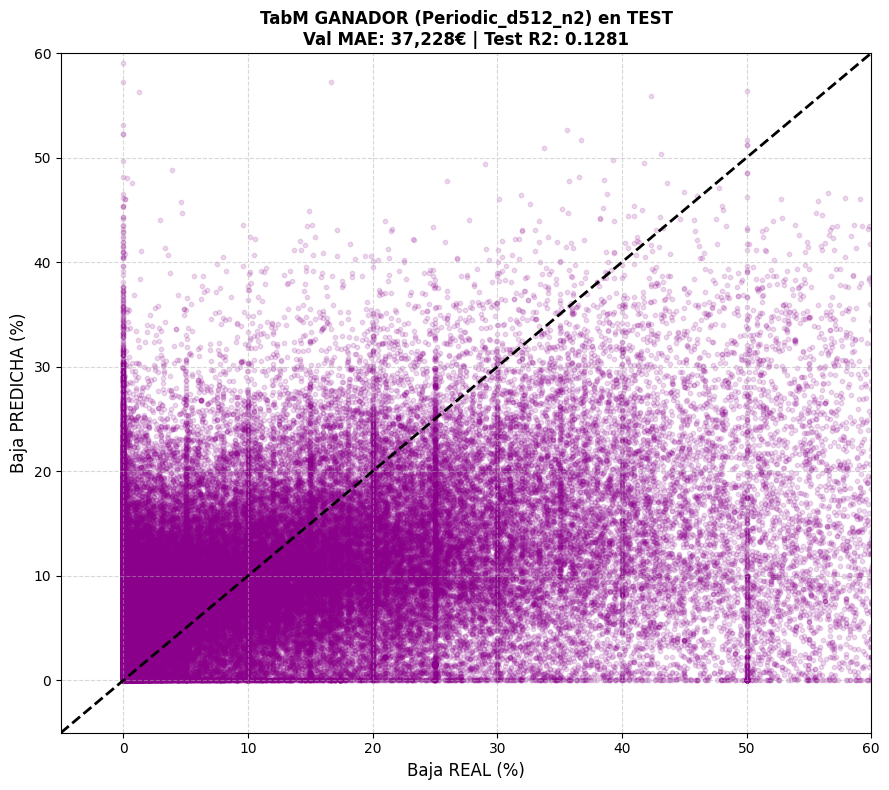

In [ ]:
# ==============================================================================
# SÚPER CELDA: GRID SEARCH TABM (Metodología Científica Pura y Test Blindado)
# ==============================================================================
!pip install tabm rtdl_num_embeddings -q

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tabm import TabM
import rtdl_num_embeddings
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
import random
import os
import gc
import shutil
import warnings
from IPython.display import display

# --- 0. Semillas y Limpieza ---
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# LLAMADA GLOBAL PARA FIJAR ALEATORIEDAD DESDE EL MINUTO CERO
set_seed(42)

# --- 1. Montaje y Rutas ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_GridSearch"
OUTPUT_DIR_TABM.mkdir(exist_ok=True)

TARGET = 'pct_baja'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
IMPORTE_COL = 'lote_importe_adjudicacion_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'

def limpiar_df_estricto(df):
    if TARGET not in df.columns:
        df[TARGET] = ((df[PRESUPUESTO].replace(0, np.nan) - df[IMPORTE_COL]) / df[PRESUPUESTO].replace(0, np.nan)) * 100
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO, IMPORTE_COL], inplace=True)
    df = df[(df[TARGET] >= 0.0) & (df[TARGET] <= 100.0)].copy()
    return df

print("--- Cargando y limpiando datos ---")
train_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
val_df_intacto   = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "val_procesado_v2_limpio.parquet"))
test_df_intacto = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

val_df = val_df_intacto.copy()
test_df = test_df_intacto.copy()

DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'lote_importe_adjudicacion_sin_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal']

for df in [train_df, val_df, test_df]:
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

# --- 2. Preprocesamiento ---
scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_val_num   = scaler_X.transform(val_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_val_cat   = encoder.transform(val_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_val_cat[:, i]   = np.where(X_val_cat[:, i] == -1, c_len, X_val_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

y_train = torch.tensor(train_df[TARGET].values, dtype=torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

# --- 3. DEFINICIÓN DEL GRID ---
configuraciones = []
for emb in ["Periodic", "PLE"]:
    for d in [256, 512]:
        for n in [2, 3]:
            configuraciones.append({"emb": emb, "d_block": d, "n_blocks": n})

resultados_grid = []
mejor_val_mae_euros_global = np.inf
nombre_ganador = ""
ruta_ganador_final = CARPETA_TFG / "TabM_GANADOR_FINAL.pth"

epochs = 40
batch_size = 128
patience = 5

print(f"\n🚀 Iniciando Grid Search ({len(configuraciones)} modelos) en {device}...")
print(f"⚖️ Criterio Único de Optimización y Selección: MAE en Euros sobre Validación\n")

val_presupuestos = val_df_intacto[PRESUPUESTO].values
val_importes_reales = val_df_intacto[IMPORTE_COL].values

for idx, conf in enumerate(configuraciones):
    nombre_exp = f"{conf['emb']}_d{conf['d_block']}_n{conf['n_blocks']}"
    print(f"[{idx+1}/{len(configuraciones)}] Entrenando: {nombre_exp}")

    set_seed(42) # Semilla por experimento para garantizar comparabilidad exacta

    if conf['emb'] == "PLE":
        num_embeddings = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
    else:
        num_embeddings = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

    model = TabM.make(
        n_num_features=len(numerical_cols),
        num_embeddings=num_embeddings,
        cat_cardinalities=cat_cardinalities if categorical_cols else None,
        d_out=1,
        k=32,
        d_block=conf['d_block'],
        n_blocks=conf['n_blocks']
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=0.0003)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    loss_fn = nn.L1Loss()

    best_val_mae_euros_epoch = np.inf
    trigger_times = 0
    ruta_guardado = CARPETA_TFG / f"TabM_TMP.pth"

    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(len(X_train_num))
        for i in range(0, len(X_train_num), batch_size):
            idx_batch = indices[i:i+batch_size]
            x_n = torch.tensor(X_train_num[idx_batch], dtype=torch.float32).to(device)
            y_b = y_train[idx_batch].to(device)
            optimizer.zero_grad()

            if categorical_cols:
                x_c = torch.tensor(X_train_cat[idx_batch], dtype=torch.long).to(device)
                preds = model(x_n, x_c).squeeze(-1)
            else:
                preds = model(x_n).squeeze(-1)

            loss = loss_fn(preds, y_b.unsqueeze(1).expand_as(preds))
            loss.backward()
            optimizer.step()

        model.eval()
        val_preds_epoch = []
        with torch.no_grad():
            for j in range(0, len(X_val_num), batch_size):
                x_v_n = torch.tensor(X_val_num[j:j+batch_size], dtype=torch.float32).to(device)
                if categorical_cols:
                    x_v_c = torch.tensor(X_val_cat[j:j+batch_size], dtype=torch.long).to(device)
                    v_out = model(x_v_n, x_v_c).squeeze(-1).mean(dim=1)
                else:
                    v_out = model(x_v_n).squeeze(-1).mean(dim=1)
                val_preds_epoch.extend(v_out.cpu().numpy())

        val_preds_pct = np.clip(np.array(val_preds_epoch), 0.0, 100.0)
        importe_predicho_val = val_presupuestos * (1 - (val_preds_pct / 100))
        val_mae_euros_actual = np.abs(val_importes_reales - importe_predicho_val).mean()

        scheduler.step(val_mae_euros_actual)

        if val_mae_euros_actual < best_val_mae_euros_epoch:
            best_val_mae_euros_epoch = val_mae_euros_actual
            torch.save(model.state_dict(), ruta_guardado)
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                break

    print(f"  -> Val MAE Euros Final: {best_val_mae_euros_epoch:,.0f}€")

    resultados_grid.append({
        "Modelo": nombre_exp,
        "Embeddings": conf['emb'],
        "d_block": conf['d_block'],
        "n_blocks": conf['n_blocks'],
        "Val_MAE_Euros": best_val_mae_euros_epoch
    })

    if best_val_mae_euros_epoch < mejor_val_mae_euros_global:
        mejor_val_mae_euros_global = best_val_mae_euros_epoch
        nombre_ganador = nombre_exp
        shutil.copy(ruta_guardado, ruta_ganador_final)

    del model, optimizer, scheduler, num_embeddings
    torch.cuda.empty_cache()
    gc.collect()
    if os.path.exists(ruta_guardado):
        os.remove(ruta_guardado)

# --- 4. EXPOSICIÓN AL CONJUNTO DE TEST (SÓLO EL GANADOR) ---
print("\n" + "="*60)
print(f"👑 GANADOR DEL GRID: {nombre_ganador} (Val MAE: {mejor_val_mae_euros_global:,.0f}€)")
print("Desprecintando el conjunto de Test para la evaluación final...")
print("="*60)

emb_ganador = nombre_ganador.split('_')[0]
d_ganador = int(nombre_ganador.split('_d')[1].split('_')[0])
n_ganador = int(nombre_ganador.split('_n')[1])

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

model_ganador.load_state_dict(torch.load(ruta_ganador_final))
model_ganador.eval()

test_preds = []
with torch.no_grad():
    for i in range(0, len(X_test_num), batch_size):
        x_t_n = torch.tensor(X_test_num[i:i+batch_size], dtype=torch.float32).to(device)
        if categorical_cols:
            x_t_c = torch.tensor(X_test_cat[i:i+batch_size], dtype=torch.long).to(device)
            t_out = model_ganador(x_t_n, x_t_c).squeeze(-1).mean(dim=1)
        else:
            t_out = model_ganador(x_t_n).squeeze(-1).mean(dim=1)
        test_preds.extend(t_out.cpu().numpy())

test_preds_porcentaje = np.clip(np.array(test_preds), 0.0, 100.0)
test_y_reales = test_df_intacto[TARGET].values

test_r2 = r2_score(test_y_reales, test_preds_porcentaje)
test_mae_pct = mean_absolute_error(test_y_reales, test_preds_porcentaje)
mask = test_y_reales != 0
test_mdape = np.median(np.abs((test_y_reales[mask] - test_preds_porcentaje[mask]) / test_y_reales[mask])) * 100 if np.sum(mask) > 0 else 0

importe_predicho_test = test_df_intacto[PRESUPUESTO] * (1 - (test_preds_porcentaje / 100))
test_mae_euros = abs(test_df_intacto[IMPORTE_COL] - importe_predicho_test).mean()

print(f"\n--- Resultados Oficiales en TEST ---")
print(f"R2 Score: {test_r2:.4f}")
print(f"MAE (%): {test_mae_pct:.4f}")
print(f"MdAPE: {test_mdape:.4f} %")
print(f"MAE en Euros: {test_mae_euros:,.2f} €")

df_resultados = pd.DataFrame(resultados_grid).sort_values(by="Val_MAE_Euros", ascending=True).reset_index(drop=True)
display(df_resultados)

# --- 5. GRÁFICO FINAL ---
plt.figure(figsize=(9, 8))
plt.scatter(test_y_reales, test_preds_porcentaje, alpha=0.15, color='darkmagenta', s=10)
plt.plot([-5, 60], [-5, 60], color='black', linestyle='--', linewidth=2)
plt.title(f'TabM GANADOR ({nombre_ganador}) en TEST\nVal MAE: {mejor_val_mae_euros_global:,.0f}€ | Test R2: {test_r2:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Baja REAL (%)', fontsize=12)
plt.ylabel('Baja PREDICHA (%)', fontsize=12)
plt.xlim(-5, 60)
plt.ylim(-5, 60)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_TABM / f'Scatter_Ganador_{nombre_ganador}.png', dpi=300)
plt.show()

df_resultados.to_excel(OUTPUT_DIR_TABM / "Resultados_GridSearch_TabM_ValEuros.xlsx", index=False)

--- GENERANDO BOXPLOT DE COMPARATIVA APE ---


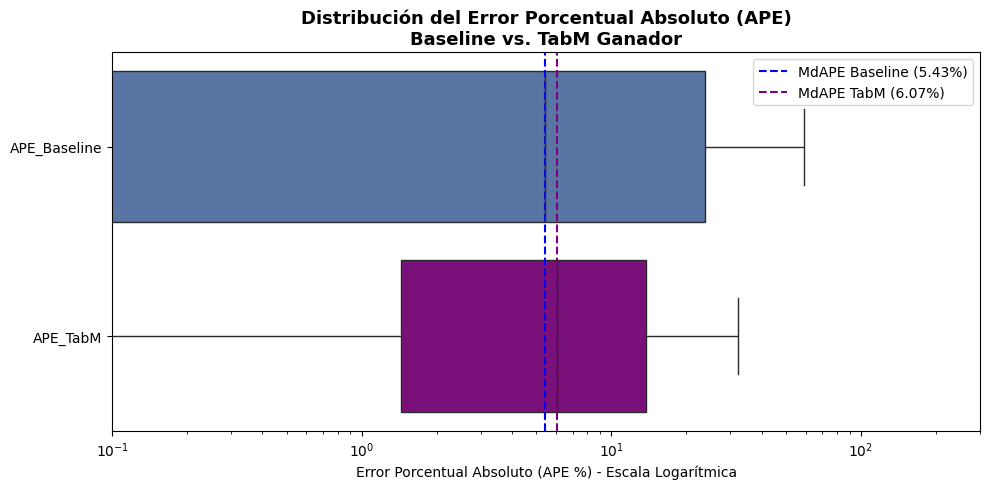

In [ ]:
# ==============================================================================
# GRÁFICO BOXPLOT APE (BASELINE vs TabM GANADOR)
# Recreación exacta del estilo usado en XGBoost
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- GENERANDO BOXPLOT DE COMPARATIVA APE ---")

try:
    # 1. Transformamos predicciones de porcentaje a euros
    presupuestos_test = test_df_intacto[PRESUPUESTO].values
    importes_reales_test = test_df_intacto[IMPORTE_COL].values

    y_pred_tabm_euros = presupuestos_test * (1 - (test_preds_porcentaje / 100.0))
    # El Baseline asume 0% de baja, por tanto Importe = Presupuesto Base
    y_pred_baseline_euros = presupuestos_test

    # 2. DataFrame de resultados
    df_results = pd.DataFrame({
        'Real': importes_reales_test,
        'Prediccion_TabM': y_pred_tabm_euros,
        'Prediccion_Baseline': y_pred_baseline_euros
    })

    # 3. Cálculo del APE (Absolute Percentage Error) para cada contrato
    df_results['APE_TabM'] = 100 * (np.abs(df_results['Real'] - df_results['Prediccion_TabM'])) / df_results['Real']
    df_results['APE_Baseline'] = 100 * (np.abs(df_results['Real'] - df_results['Prediccion_Baseline'])) / df_results['Real']

    # 4. Gráfico Boxplot APE
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_results[['APE_Baseline', 'APE_TabM']],
        orient='h',
        showfliers=False, # Sin outliers (idéntico a XGBoost)
        palette=['#4C72B0', 'darkmagenta'] # Azul (Baseline) vs Morado (TabM)
    )

    plt.title('Distribución del Error Porcentual Absoluto (APE)\nBaseline vs. TabM Ganador', fontsize=13, fontweight='bold')
    plt.xlabel('Error Porcentual Absoluto (APE %) - Escala Logarítmica')
    plt.gca().set_xscale('log')
    plt.xlim(0.1, 300)

    # Líneas verticales para las medianas (MdAPE)
    median_baseline = df_results['APE_Baseline'].median()
    median_tabm = df_results['APE_TabM'].median()

    plt.axvline(x=median_baseline, color='blue', linestyle='--', label=f"MdAPE Baseline ({median_baseline:.2f}%)")
    plt.axvline(x=median_tabm, color='purple', linestyle='--', label=f"MdAPE TabM ({median_tabm:.2f}%)")

    plt.legend()
    plt.tight_layout()

    # Guardamos con el mismo patrón de nombre
    plt.savefig(OUTPUT_DIR_TABM / '1_comparativa_error_boxplot_TabM_Baja.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"Error generando el gráfico: {e}")

--- GENERANDO SCATTER PLOT EN EUROS (ESCALA LOG) ---


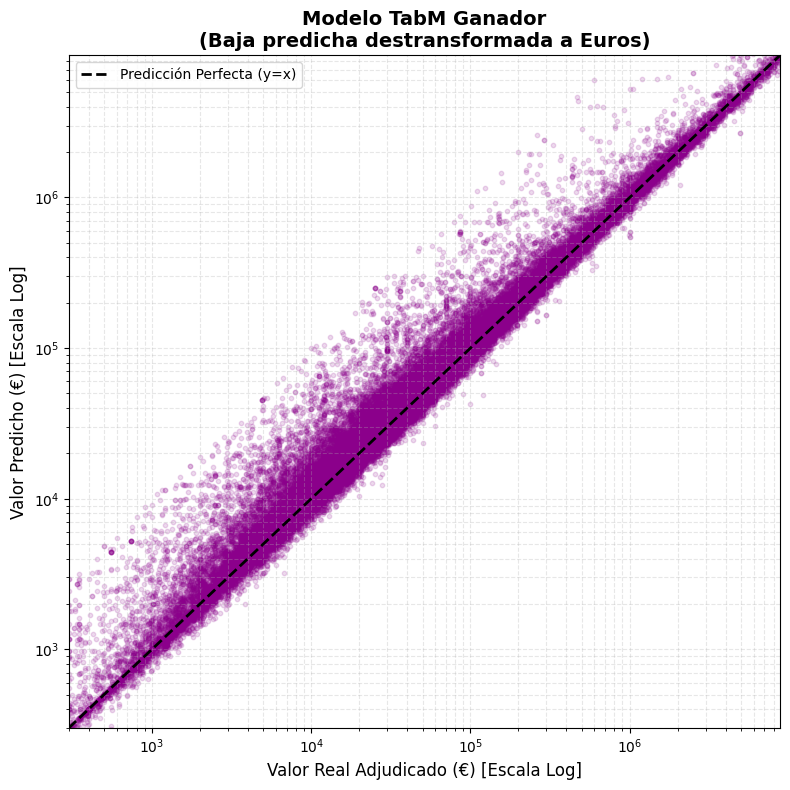

In [ ]:
# ==============================================================================
# GRÁFICO SCATTER (TabM) - EUROS EN ESCALA LOGARÍTMICA
# Recreación exacta del estilo de XGBoost y Ridge
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- GENERANDO SCATTER PLOT EN EUROS (ESCALA LOG) ---")

try:
    # 1. Recuperamos los datos (Asumiendo que test_preds_porcentaje sigue en memoria)
    presupuestos_test = test_df_intacto[PRESUPUESTO].values
    importes_reales_test = test_df_intacto[IMPORTE_COL].values

    # Transformamos la baja predicha a Euros
    y_pred_tabm_euros = presupuestos_test * (1 - (test_preds_porcentaje / 100.0))

    # 2. DataFrame para pintar
    df_results = pd.DataFrame({
        'Real': importes_reales_test,
        'Prediccion_TabM': y_pred_tabm_euros
    })

    # Límites para el zoom (Igual que en el script de XGBoost)
    min_val_zoom = max(10.0, df_results['Real'].quantile(0.005))
    max_val_zoom = df_results['Real'].quantile(0.995)

    # 3. Dibujamos el gráfico
    plt.figure(figsize=(8, 8))

    # Usamos el color morado que le asignamos a TabM
    plt.scatter(df_results['Real'], df_results['Prediccion_TabM'], alpha=0.15, s=10, color='darkmagenta')

    plt.xscale('log')
    plt.yscale('log')
    plt.plot([min_val_zoom, max_val_zoom], [min_val_zoom, max_val_zoom], color='black', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

    plt.title("Modelo TabM Ganador\n(Baja predicha destransformada a Euros)", fontsize=14, fontweight='bold')
    plt.xlabel("Valor Real Adjudicado (€) [Escala Log]", fontsize=12)
    plt.ylabel("Valor Predicho (€) [Escala Log]", fontsize=12)

    plt.xlim(min_val_zoom, max_val_zoom)
    plt.ylim(min_val_zoom, max_val_zoom)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Guardamos la imagen
    plt.savefig(OUTPUT_DIR_TABM / '3_scatter_TabM_Baja_Zoom.png', dpi=300)
    plt.show()

except Exception as e:
    print(f"Error generando el gráfico: {e}")

--- 1. Preparando el entorno para Colab y SHAP ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 2. Cargando y transformando datos desde Drive ---
--- 3. Cargando el modelo ganador desde Drive ---
--- 4. Calculando SHAP (KernelExplainer de Alta Densidad) ---
Calculando SHAP para 1500 muestras (Aprovechando GPU T4)...


  0%|          | 0/1500 [00:00<?, ?it/s]

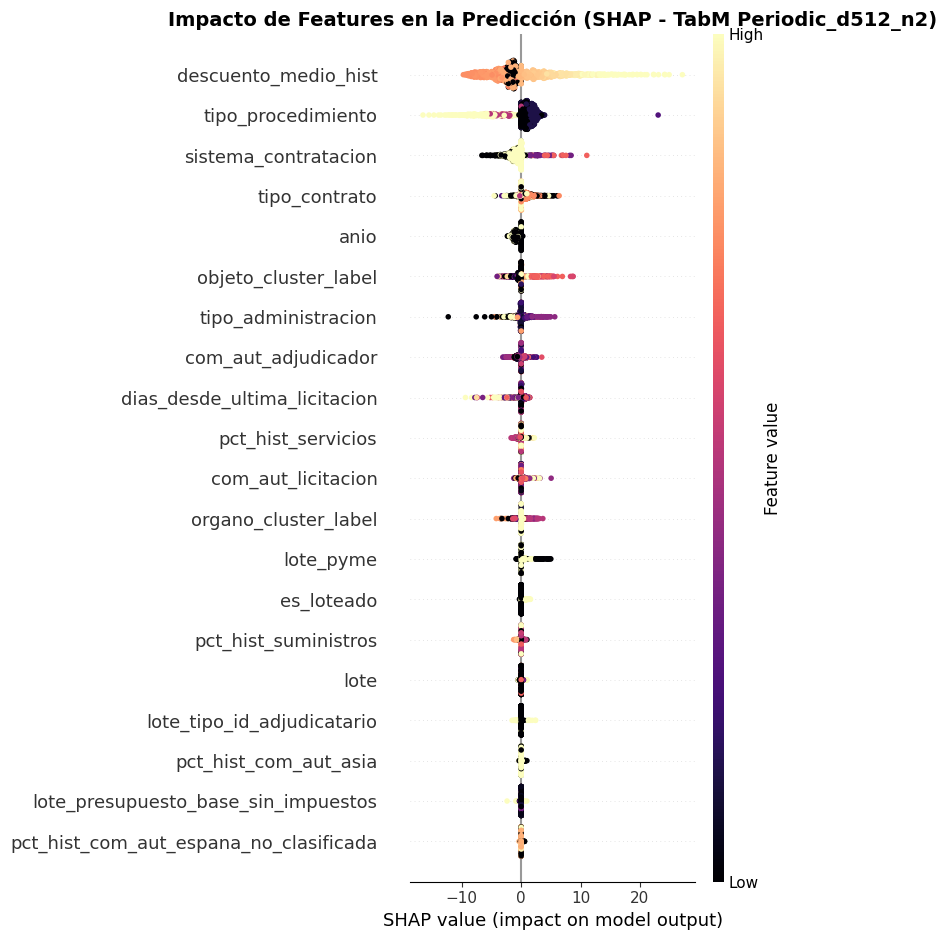

✅ SHAP plot de Alta Densidad guardado en: /content/drive/MyDrive/TFG_Final_Contratacion/salida_graficos_TabM_GridSearch/shap_summary_plot_TabM_Periodic_d512_n2_Kernel_AltaDensidad.png


In [ ]:
# ==============================================================================
# SCRIPT EXPRESS COLAB: EXPLICABILIDAD SHAP PARA TABM (KernelExplainer)
# ==============================================================================
!pip install tabm rtdl_num_embeddings shap -q

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tabm import TabM
import rtdl_num_embeddings
import shap
import matplotlib.pyplot as plt
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

print("--- 1. Preparando el entorno para Colab y SHAP ---")
try:
    drive.mount('/content/drive')
except:
    print("Drive ya montado o error al montar")

CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_GridSearch"
OUTPUT_DIR_TABM.mkdir(exist_ok=True)

TARGET = 'pct_baja'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
IMPORTE_COL = 'lote_importe_adjudicacion_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'

def limpiar_df_estricto(df):
    if TARGET not in df.columns:
        df[TARGET] = ((df[PRESUPUESTO].replace(0, np.nan) - df[IMPORTE_COL]) / df[PRESUPUESTO].replace(0, np.nan)) * 100
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO, IMPORTE_COL], inplace=True)
    df = df[(df[TARGET] >= 0.0) & (df[TARGET] <= 100.0)].copy()
    return df

print("--- 2. Cargando y transformando datos desde Drive ---")
train_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
test_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'lote_importe_adjudicacion_sin_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal']

train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns], inplace=True, errors='ignore')
test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

print("--- 3. Cargando el modelo ganador desde Drive ---")
NOMBRE_GANADOR = "Periodic_d512_n2" # <--- CAMBIA ESTO SI ES NECESARIO
ruta_ganador_final = CARPETA_TFG / "TabM_GANADOR_FINAL.pth"

emb_ganador = NOMBRE_GANADOR.split('_')[0]
d_ganador = int(NOMBRE_GANADOR.split('_d')[1].split('_')[0])
n_ganador = int(NOMBRE_GANADOR.split('_n')[1])

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

model_ganador.load_state_dict(torch.load(ruta_ganador_final, map_location=device))
model_ganador.eval()

print("--- 4. Calculando SHAP (KernelExplainer de Alta Densidad) ---")
try:
    # 🚀 ¡AUMENTAMOS LAS MUESTRAS RADICALMENTE!
    n_background = 200   # Fondo más rico
    n_test_sample = 1500 # 1500 puntos en lugar de 200 = Nube mucho más densa

    bg_indices = np.random.choice(len(X_train_num), n_background, replace=False)
    test_indices = np.random.choice(len(X_test_num), n_test_sample, replace=False)

    all_feature_names = numerical_cols + (categorical_cols if categorical_cols else [])

    # Preparamos los datos como arrays de Numpy para KernelExplainer
    if categorical_cols:
        X_train_bg_np = np.concatenate([X_train_num[bg_indices], X_train_cat[bg_indices]], axis=1)
        X_test_sample_np = np.concatenate([X_test_num[test_indices], X_test_cat[test_indices]], axis=1)

        # Función de predicción "caja negra" que aprovecha la GPU T4
        def predict_fn(x_np):
            model_ganador.eval()
            with torch.no_grad():
                x_tensor = torch.tensor(x_np).to(device) # Envía a la GPU
                x_n = x_tensor[:, :len(numerical_cols)].float()
                x_c = x_tensor[:, len(numerical_cols):].long()
                preds = model_ganador(x_n, x_c).squeeze(-1).mean(dim=1)
            return preds.cpu().numpy()

    else:
        X_train_bg_np = X_train_num[bg_indices]
        X_test_sample_np = X_test_num[test_indices]

        def predict_fn(x_np):
            model_ganador.eval()
            with torch.no_grad():
                x_n = torch.tensor(x_np, dtype=torch.float32).to(device)
                preds = model_ganador(x_n).squeeze(-1).mean(dim=1)
            return preds.cpu().numpy()

    print(f"Calculando SHAP para {n_test_sample} muestras (Aprovechando GPU T4)...")

    # Aumentamos los centroides de k-means de 20 a 50 para mayor precisión matemática
    explainer = shap.KernelExplainer(predict_fn, shap.kmeans(X_train_bg_np, 50))

    # Aumentamos la resolución de Shapley de 100 a 500 iteraciones
    # (Esto sí que tardará unos minutos, verás la barra de progreso)
    shap_values = explainer.shap_values(X_test_sample_np, nsamples=500)

    # Formato seguro
    if isinstance(shap_values, list):
        shap_values_array = shap_values[0]
    else:
        shap_values_array = shap_values

    # Dibujar y guardar
    plt.figure(figsize=(10, 8))
    # Usamos cmap="magma" para que quede visualmente coherente con tus otros gráficos
    shap.summary_plot(shap_values_array, X_test_sample_np, feature_names=all_feature_names, show=False, cmap="magma")

    plt.title(f"Impacto de Features en la Predicción (SHAP - TabM {NOMBRE_GANADOR})", fontsize=14, fontweight='bold')
    plt.tight_layout()

    ruta_shap = OUTPUT_DIR_TABM / f"shap_summary_plot_TabM_{NOMBRE_GANADOR}_Kernel_AltaDensidad.png"
    plt.savefig(ruta_shap, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ SHAP plot de Alta Densidad guardado en: {ruta_shap}")

except Exception as e:
    print(f"❌ Error al calcular SHAP para TabM: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
# ==============================================================================
# SCRIPT EXPRESS: DESCIFRANDO LAS CATEGÓRICAS Y SHAP
# ==============================================================================
import pandas as pd
import numpy as np

print("--- DESCIFRANDO EL ENCODER CATEGÓRICO ---")

# 1. Recuperamos el diccionario del encoder que entrenaste antes
# (asumiendo que la variable 'encoder' y 'categorical_cols' siguen en memoria)
for i, col in enumerate(categorical_cols):
    if col in ['tipo_procedimiento', 'sistema_contratacion']:
        print(f"\n🔹 Variable: {col}")
        print("-" * 40)
        # Las categorías están guardadas en el mismo orden que sus IDs (0, 1, 2...)
        categorias = encoder.categories_[i]
        for id_cat, nombre_cat in enumerate(categorias):
            print(f"  ID {id_cat} (Color SHAP {'Oscuro' if id_cat < len(categorias)/2 else 'Claro/Amarillo'}) -> {nombre_cat}")


print("\n" + "="*60)
print("--- RELACIONANDO SHAP CON CATEGORÍAS ---")
# 2. Vamos a sacar la media del valor SHAP para cada categoría real en test
# (asumiendo que 'shap_values_array' y 'X_test_cat' siguen en memoria)

# Aseguramos que tenemos los nombres de las variables
all_feature_names = numerical_cols + categorical_cols

for col_name in ['tipo_procedimiento', 'sistema_contratacion']:
    if col_name in all_feature_names:
        # Encontramos el índice de la columna en el array final de SHAP
        idx_shap = all_feature_names.index(col_name)
        # Encontramos el índice de la columna solo en las categóricas
        idx_cat = categorical_cols.index(col_name)

        # Recuperamos los nombres reales
        nombres_categorias = encoder.categories_[idx_cat]

        # Para cada categoría, calculamos su impacto medio
        resultados_cat = []
        for id_cat, nombre_cat in enumerate(nombres_categorias):
            # Filtramos los contratos de test que tienen esta categoría exacta
            # X_test_cat tiene las categóricas codificadas (0, 1, 2...)
            mascara = (X_test_cat[test_indices, idx_cat] == id_cat)

            # Si hay contratos de este tipo en nuestra muestra de test
            if np.sum(mascara) > 0:
                # Calculamos la media de los valores SHAP para esos contratos
                impacto_medio = np.mean(shap_values_array[mascara, idx_shap])
                resultados_cat.append((nombre_cat, impacto_medio, np.sum(mascara)))

        # Ordenamos por impacto (de más negativo a más positivo)
        resultados_cat.sort(key=lambda x: x[1])

        print(f"\n📊 Impacto SHAP medio por categoría para: {col_name}")
        print("-" * 60)
        for nombre, impacto, cuenta in resultados_cat:
            if impacto < -1:
                efecto = "📉 Reduce la baja mucho"
            elif impacto < -0.1:
                efecto = "↘️ Reduce la baja levemente"
            elif impacto > 1:
                efecto = "📈 Aumenta la baja mucho"
            elif impacto > 0.1:
                efecto = "↗️ Aumenta la baja levemente"
            else:
                efecto = "➖ Impacto casi nulo"

            print(f"{efecto.ljust(30)} | Impacto: {impacto:>+6.2f}% | Casos: {cuenta:>3} | Categ: {nombre}")

print("\n(Nota: Solo se muestran las categorías que han aparecido en la muestra aleatoria de Test usada para SHAP)")

--- DESCIFRANDO EL ENCODER CATEGÓRICO ---

🔹 Variable: sistema_contratacion
----------------------------------------
  ID 0 (Color SHAP Oscuro) -> contrato basado en un acuerdo marco
  ID 1 (Color SHAP Oscuro) -> contrato basado en un sistema dinamico de adquisicia3n
  ID 2 (Color SHAP Claro/Amarillo) -> establecimiento del acuerdo marco
  ID 3 (Color SHAP Claro/Amarillo) -> no aplica

🔹 Variable: tipo_procedimiento
----------------------------------------
  ID 0 (Color SHAP Oscuro) -> abierto
  ID 1 (Color SHAP Oscuro) -> abierto simplificado
  ID 2 (Color SHAP Oscuro) -> basado en un sistema dinamico de adquisicia3n
  ID 3 (Color SHAP Oscuro) -> concurso de proyectos
  ID 4 (Color SHAP Oscuro) -> derivado de acuerdo marco
  ID 5 (Color SHAP Oscuro) -> dialogo competitivo
  ID 6 (Color SHAP Claro/Amarillo) -> licitacia3n con negociacia3n
  ID 7 (Color SHAP Claro/Amarillo) -> negociado con publicidad
  ID 8 (Color SHAP Claro/Amarillo) -> negociado sin publicidad
  ID 9 (Color SHAP Clar

In [2]:
# ==============================================================================
# CELDA INDEPENDIENTE: DIAGNÓSTICO DE OVERFITTING DEL GANADOR TABM
# (Sin re-entrenar, cargando pesos guardados)
# ==============================================================================
!pip install tabm rtdl_num_embeddings -q

import os
from google.colab import drive
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error
from tabm import TabM
import rtdl_num_embeddings
import warnings

warnings.filterwarnings('ignore')

# --- 1. Rutas y Configuración ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

CARPETA_TFG = Path("/content/drive/MyDrive/TFG_Final_Contratacion")
OUTPUT_DIR_TABM = CARPETA_TFG / "salida_graficos_TabM_GridSearch"
RUTA_GANADOR = CARPETA_TFG / "TabM_GANADOR_FINAL.pth"
RUTA_EXCEL = OUTPUT_DIR_TABM / "Resultados_GridSearch_TabM_ValEuros.xlsx"

TARGET = 'pct_baja'
PRESUPUESTO = 'lote_presupuesto_base_sin_impuestos'
IMPORTE_COL = 'lote_importe_adjudicacion_sin_impuestos'
VALOR_ESTIMADO = 'valor_estimado_imputado'
batch_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def limpiar_df_estricto(df):
    if TARGET not in df.columns:
        df[TARGET] = ((df[PRESUPUESTO].replace(0, np.nan) - df[IMPORTE_COL]) / df[PRESUPUESTO].replace(0, np.nan)) * 100
    if 'es_exito' in df.columns: df = df[df['es_exito'] == 1].copy()
    if PRESUPUESTO in df.columns and VALOR_ESTIMADO in df.columns:
        df = df[df[PRESUPUESTO] <= df[VALOR_ESTIMADO]].copy()
        df = df[df[VALOR_ESTIMADO] <= (df[PRESUPUESTO] * 10)].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=[TARGET, PRESUPUESTO, IMPORTE_COL], inplace=True)
    df = df[(df[TARGET] >= 0.0) & (df[TARGET] <= 100.0)].copy()
    return df

print("⏳ Cargando datos y preprocesando...")
train_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "train_procesado_v2_limpio.parquet"))
test_df = limpiar_df_estricto(pd.read_parquet(CARPETA_TFG / "test_procesado_v2_limpio.parquet"))

DROP_COLS = ['_id', 'id', 'fecha_primera_publicacion', 'objeto', 'lote_objeto', 'organo_contratacion', 'lote_adjudicatario', 'lote_resultado', 'cpv_final_imputado', 'cif_normalizado', 'lote_importe_adjudicacion_con_impuestos', 'lote_importe_adjudicacion_sin_impuestos', 'es_exito', 'es_sobrecoste', 'lote_numero_ofertas_recibidas', 'presupuesto_medio_hist', 'descuento_promedio', 'lote_precio_oferta_mas_alta', 'lote_precio_oferta_mas_baja', 'duracion_proceso_dias', 'es_anomalia_temporal']

for df in [train_df, test_df]:
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')

features = [col for col in train_df.columns if col != TARGET]
categorical_cols = train_df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = train_df[features].select_dtypes(exclude=['object', 'category', 'bool']).columns.tolist()

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(train_df[numerical_cols]).astype(np.float32)
X_test_num  = scaler_X.transform(test_df[numerical_cols]).astype(np.float32)

cat_cardinalities = []
if categorical_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_cat = encoder.fit_transform(train_df[categorical_cols]).astype(np.int64)
    X_test_cat  = encoder.transform(test_df[categorical_cols]).astype(np.int64)
    for i, col in enumerate(categorical_cols):
        c_len = len(encoder.categories_[i])
        cat_cardinalities.append(c_len + 1)
        X_train_cat[:, i] = np.where(X_train_cat[:, i] == -1, c_len, X_train_cat[:, i])
        X_test_cat[:, i]  = np.where(X_test_cat[:, i] == -1, c_len, X_test_cat[:, i])

bins = rtdl_num_embeddings.compute_bins(torch.tensor(X_train_num, dtype=torch.float32))

# --- 2. Leer Excel para reconstruir la arquitectura del ganador ---
df_resultados = pd.read_excel(RUTA_EXCEL)
mejor_modelo = df_resultados.iloc[0] # El primero es el ganador (ordenado por MAE Val)
emb_ganador = mejor_modelo['Embeddings']
d_ganador = int(mejor_modelo['d_block'])
n_ganador = int(mejor_modelo['n_blocks'])

print(f"✅ Arquitectura ganadora recuperada: Embeddings={emb_ganador}, d_block={d_ganador}, n_blocks={n_ganador}")

if emb_ganador == "PLE":
    num_embeddings_final = rtdl_num_embeddings.PiecewiseLinearEmbeddings(bins=bins, d_embedding=16, activation=False, version="B")
else:
    num_embeddings_final = rtdl_num_embeddings.PeriodicEmbeddings(n_features=len(numerical_cols), d_embedding=16, lite=False)

model_ganador = TabM.make(
    n_num_features=len(numerical_cols),
    num_embeddings=num_embeddings_final,
    cat_cardinalities=cat_cardinalities if categorical_cols else None,
    d_out=1,
    k=32,
    d_block=d_ganador,
    n_blocks=n_ganador
).to(device)

# --- 3. Cargar Pesos Guardados ---
model_ganador.load_state_dict(torch.load(RUTA_GANADOR, map_location=device))
model_ganador.eval()

# --- 4. Inferir en Train y Test ---
print("🧠 Ejecutando inferencia en Train y Test...")

def predecir_lotes(X_num, X_cat=None):
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_num), batch_size):
            x_n = torch.tensor(X_num[i:i+batch_size], dtype=torch.float32).to(device)
            if categorical_cols:
                x_c = torch.tensor(X_cat[i:i+batch_size], dtype=torch.long).to(device)
                out = model_ganador(x_n, x_c).squeeze(-1).mean(dim=1)
            else:
                out = model_ganador(x_n).squeeze(-1).mean(dim=1)
            preds.extend(out.cpu().numpy())
    return np.clip(np.array(preds), 0.0, 100.0)

train_preds_pct = predecir_lotes(X_train_num, X_train_cat if categorical_cols else None)
test_preds_pct = predecir_lotes(X_test_num, X_test_cat if categorical_cols else None)

train_mae_pct = mean_absolute_error(train_df[TARGET].values, train_preds_pct)
test_mae_pct = mean_absolute_error(test_df[TARGET].values, test_preds_pct)

# --- 5. Resultados ---
print("\n" + "="*60)
print("--- DIAGNÓSTICO DE OVERFITTING (TabM - ESCALA NATIVA) ---")
print(f"MAE Train: {train_mae_pct:.2f}% |  MAE Test: {test_mae_pct:.2f}%")

if train_mae_pct > 0:
    diferencia_mae_pct = ((test_mae_pct - train_mae_pct) / train_mae_pct) * 100
    print(f"-> Degradación del MAE en Test: {diferencia_mae_pct:+.1f}%")
print("="*60)

Mounted at /content/drive
⏳ Cargando datos y preprocesando...
✅ Arquitectura ganadora recuperada: Embeddings=Periodic, d_block=512, n_blocks=2
🧠 Ejecutando inferencia en Train y Test...

--- DIAGNÓSTICO DE OVERFITTING (TabM - ESCALA NATIVA) ---
MAE Train: 8.62% |  MAE Test: 9.40%
-> Degradación del MAE en Test: +9.1%
